In [1]:
import os
import sys
import gc
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras import layers, models, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

2026-01-13 12:56:57.800013: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-13 12:56:58.845155: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-13 12:56:59.157379: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-13 12:57:01.135389: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%load_ext autoreload
%autoreload 2

# Pega o diretório atual e sobe um nível ('..')
project_root = os.path.abspath('..')

# Adiciona este diretório ao sys.path se ele ainda não estiver lá
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Seus imports originais ---
import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

In [3]:
# --- 2. CONFIGURAÇÕES DE AMBIENTE E CAMINHOS ---
# Configuração básica de GPU (Memory Growth) para evitar alocação total imediata
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

I0000 00:00:1768319935.991056  286839 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768319935.997274  286839 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768319935.997338  286839 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# DEFINA SEUS CAMINHOS AQUI:
BASE_DIR = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI"
data_3t_dir = os.path.join(BASE_DIR, "ADNI_3_4_NORMALIZED")
results_dir = os.path.join(BASE_DIR, "results", "fine_tuning_3t_k_fold")
os.makedirs(results_dir, exist_ok=True)

# Nome do modelo pré-treinado (Treinado no dataset 1.5T)
# pretrained_model_path = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_1/binary_classifier_noise_200_epochs_batch_15_2_classes.keras"

# Carregando último modelo treinado
latest_results = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3"
n_results = len(os.listdir(latest_results))
latest_dir = os.path.join(latest_results, f"test_{n_results}")
pretrained_model_path = os.path.join(latest_dir, os.listdir(latest_dir)[0])

In [6]:
# A pasta de resultados é organizada por pastas para cada teste
# Aqui, testamos quantas pastas já existem
n = len(os.listdir(results_dir))

# Caso já existam pastas, testamos se estas estão com conteúdo. Caso alguma não tenha conteúdo suficiente (treino foi interrompido
# e apenas parte dos resultados foi salva), nós apagamos a pasta "test_x" e recriamos.
if (n > 0):
    if (len(os.listdir(os.path.join(results_dir, f'test_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir, f"test_{n}")):
            os.remove(os.path.join(results_dir,  f"test_{n}", item))
        os.removedirs(os.path.join(results_dir, f'test_{n}'))
        n -= 1

# Criação da pasta
folder_name = f"test_{str(n+1)}"
results_dir = os.path.join(results_dir, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_2 criada


In [7]:
# === 4. PREPARAÇÃO DOS DADOS 3T (União de todas as pastas) ===
print("--- Carregando e Unificando Dados 3T ---")

dir_3t_train = os.path.join(data_3t_dir, "train")
dir_3t_val = os.path.join(data_3t_dir, "validation")
dir_3t_test = os.path.join(data_3t_dir, "test")

parts_X = []
parts_y = []

# Carrega tudo usando a função do seu módulo local
for d in [dir_3t_train, dir_3t_val, dir_3t_test]:
    print(f"Lendo pasta: {d}")
    try:
        x_part, y_part = proc_dados.load_nifti_data(d)
        if len(x_part) > 0:
            parts_X.append(x_part)
            parts_y.append(y_part)
    except Exception as e:
        print(f"Erro ao ler pasta {d}: {e}")

if len(parts_X) > 0:
    X_3t_all = np.concatenate(parts_X, axis=0)
    y_3t_all = np.concatenate(parts_y, axis=0)
    print(f"Total de dados 3T para K-Fold: {X_3t_all.shape}")
else:
    raise ValueError("Não foram encontrados dados nas pastas 3T.")

del parts_X, parts_y

# === 5. CONFIGURAÇÃO DO K-FOLD E MODELO ===
BATCH_SIZE = 8
EPOCHS = 50
K_FOLDS = 5
LEARNING_RATE = 0.001
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Listas para armazenar métricas de cada fold
fold_accuracies = []
fold_aucs = []
all_true_labels = []
all_pred_labels = []

print(f"\n>>> INICIANDO FINE-TUNING (K-FOLD = {K_FOLDS}) <<<")
print(f"Modelo Base para carregar pesos: {pretrained_model_path}")
print("Estratégia: Congelar 1º Bloco Convolucional\n")

# Verifica se o modelo base existe antes de começar o loop
if not os.path.exists(pretrained_model_path):
    raise FileNotFoundError(f"Modelo pré-treinado não encontrado em: {pretrained_model_path}")

--- Carregando e Unificando Dados 3T ---
Lendo pasta: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/train
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/train


Lendo ad: 100%|██████████| 88/88 [00:10<00:00,  8.46it/s]


Dados carregados. Shape: (699, 156, 195, 160, 1)
Lendo pasta: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/validation
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/validation


Lendo ad: 100%|██████████| 27/27 [00:03<00:00,  8.72it/s]


Dados carregados. Shape: (202, 156, 195, 160, 1)
Lendo pasta: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/test
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/test


Lendo ad: 100%|██████████| 13/13 [00:01<00:00,  8.78it/s]


Dados carregados. Shape: (102, 156, 195, 160, 1)
Total de dados 3T para K-Fold: (1003, 156, 195, 160, 1)

>>> INICIANDO FINE-TUNING (K-FOLD = 5) <<<
Modelo Base para carregar pesos: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_2/binary_classifier_noise_200_epochs_batch_8_2_classes.keras
Estratégia: Congelar 1º Bloco Convolucional




INICIANDO FOLD 1/5 (FINE-TUNING COM AUGMENTATION)
⏳ Gerando Augmentation e Balanceamento na RAM...
   > Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
   > Alocando memória para 1108 amostras (float16). Shape final: (1108, 156, 195, 160, 1)
    Processando: 800/802...
Dados Augmentados na RAM! Shape: (1108, 156, 195, 160, 1)
Configurando tf.data Generators...


I0000 00:00:1768320376.065785  286839 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768320376.065860  286839 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768320376.065883  286839 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768320376.369806  286839 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768320376.369867  286839 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-13

Carregando modelo base de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_2/binary_classifier_noise_200_epochs_batch_8_2_classes.keras
Pesos carregados com sucesso.
   Congelando camadas iniciais (0 a 12)...
🚀 Iniciando Fine-Tuning...
Epoch 1/50


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 46 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1768320380.966489  288817 service.cc:146] XLA service 0x7efdc0813030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768320380.966535  288817 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-13 13:06:21.224619: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-13 13:06:21.655201: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-01-13 13:06:25.590157: E external/local_xla/xla/servic

    138/Unknown 31s 55ms/step - accuracy: 0.7793 - auc: 0.8400 - loss: 0.9034

...

138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9493 - auc: 0.9851 - loss: 0.2697

2026-01-13 13:10:30.070849: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813


139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.9404 - auc: 0.9826 - loss: 0.2782 - val_accuracy: 0.8806 - val_auc: 0.8560 - val_loss: 0.4072 - learning_rate: 2.5000e-04
Epoch 24/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.9332 - auc: 0.9798 - loss: 0.2815 - val_accuracy: 0.8706 - val_auc: 0.8571 - val_loss: 0.4134 - learning_rate: 2.5000e-04
Epoch 25/50
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9404 - auc: 0.9866 - loss: 0.2616

2026-01-13 13:10:47.930411: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
2026-01-13 13:10:47.930499: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9359 - auc: 0.9820 - loss: 0.2744 - val_accuracy: 0.8806 - val_auc: 0.8512 - val_loss: 0.4505 - learning_rate: 2.5000e-04


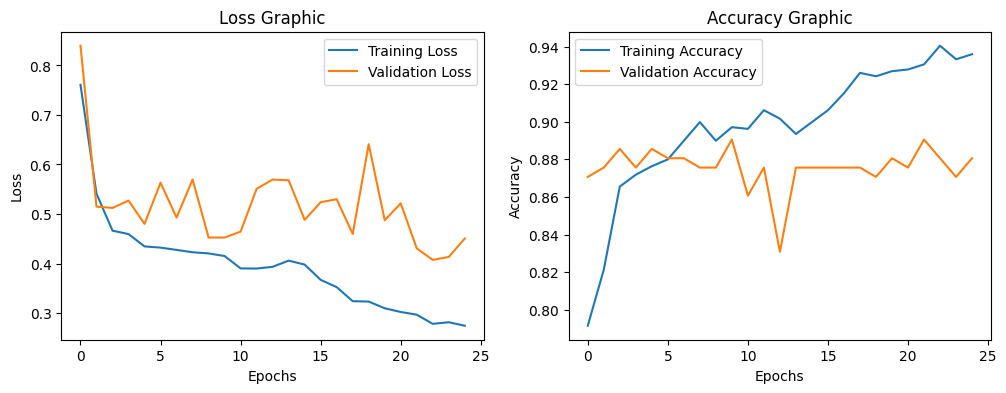

Carregando melhor modelo do fold para avaliação...
   Resultado Fold 1: Acc=0.8905, AUC=0.8390
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       175
           1       0.83      0.19      0.31        26

    accuracy                           0.89       201
   macro avg       0.86      0.59      0.63       201
weighted avg       0.88      0.89      0.86       201



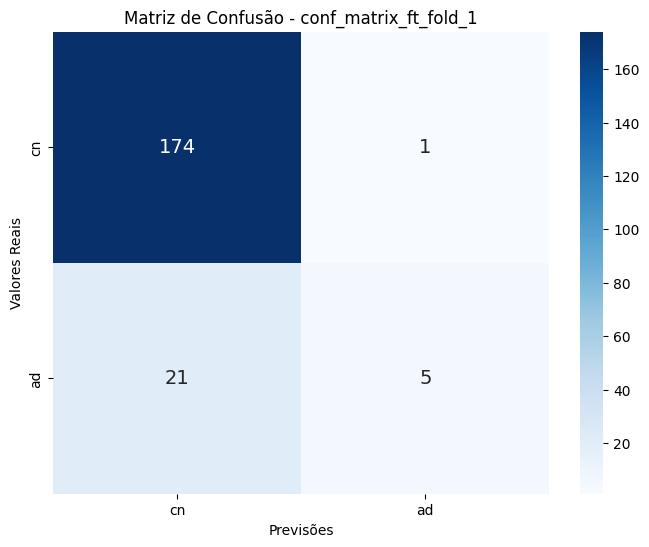

🧹 Limpando memória...

INICIANDO FOLD 2/5 (FINE-TUNING COM AUGMENTATION)
⏳ Gerando Augmentation e Balanceamento na RAM...
   > Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
   > Alocando memória para 1108 amostras (float16). Shape final: (1108, 156, 195, 160, 1)
    Processando: 800/802...
Dados Augmentados na RAM! Shape: (1108, 156, 195, 160, 1)
Configurando tf.data Generators...
Carregando modelo base de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_2/binary_classifier_noise_200_epochs_batch_8_2_classes.keras
Pesos carregados com sucesso.
   Congelando camadas iniciais (0 a 12)...
🚀 Iniciando Fine-Tuning...
Epoch 1/50


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 46 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


    139/Unknown 19s 88ms/step - accuracy: 0.7325 - auc: 0.8033 - loss: 1.0389

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-01-13 13:14:06.240115: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %reduce-window.133 = f32[1,39,49,40,4]{4,3,2,1,0} reduce-window(f32[1,156,195,160,4]{4,3,2,1,0} %broadcast.121, f32[] %constant.122), window={size=1x4x4x4x1 stride=1x4x4x4x1 pad=0_0x0_0x0_1x0_0x0_0}, to_apply=%region_1.129, metadata={op_type="AvgPool3D" op_name="Small_Leaky_3D_Model_1/average_pooling3d_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has

139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 143ms/step - accuracy: 0.7825 - auc: 0.8538 - loss: 0.7887 - val_accuracy: 0.8756 - val_auc: 0.7203 - val_loss: 0.7815 - learning_rate: 0.0010
Epoch 2/50
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8449 - auc: 0.9053 - loss: 0.5141

...

2026-01-13 13:18:13.538378: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
2026-01-13 13:18:13.538470: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9526 - auc: 0.9823 - loss: 0.2400

2026-01-13 13:18:21.137816: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
2026-01-13 13:18:21.137919: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.9486 - auc: 0.9873 - loss: 0.2271 - val_accuracy: 0.8657 - val_auc: 0.7844 - val_loss: 0.4733 - learning_rate: 1.2500e-04


2026-01-13 13:18:22.458667: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
2026-01-13 13:18:22.458757: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


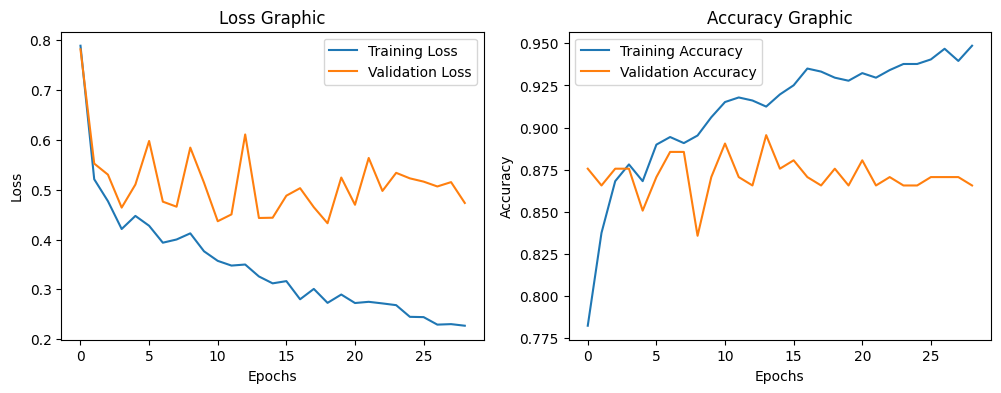

Carregando melhor modelo do fold para avaliação...
   Resultado Fold 2: Acc=0.8955, AUC=0.7975
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       175
           1       0.69      0.35      0.46        26

    accuracy                           0.90       201
   macro avg       0.80      0.66      0.70       201
weighted avg       0.88      0.90      0.88       201



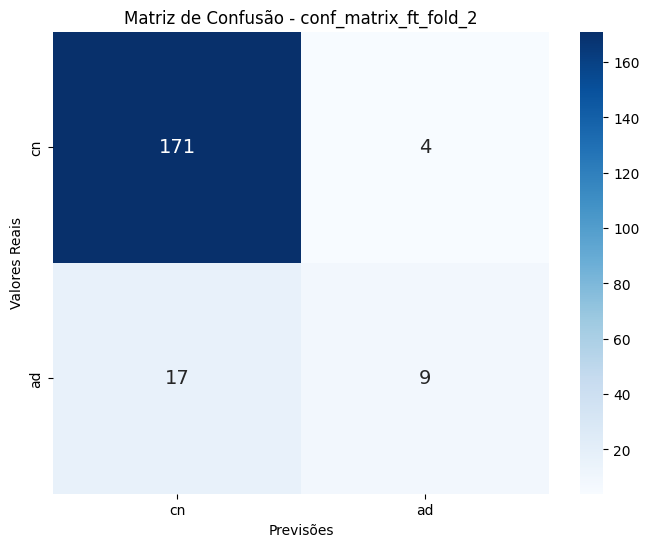

🧹 Limpando memória...

INICIANDO FOLD 3/5 (FINE-TUNING COM AUGMENTATION)
⏳ Gerando Augmentation e Balanceamento na RAM...
   > Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
   > Alocando memória para 1108 amostras (float16). Shape final: (1108, 156, 195, 160, 1)
    Processando: 800/802...
Dados Augmentados na RAM! Shape: (1108, 156, 195, 160, 1)
Configurando tf.data Generators...
Carregando modelo base de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_2/binary_classifier_noise_200_epochs_batch_8_2_classes.keras
Pesos carregados com sucesso.
   Congelando camadas iniciais (0 a 12)...
🚀 Iniciando Fine-Tuning...
Epoch 1/50


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 46 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


    139/Unknown 17s 82ms/step - accuracy: 0.7037 - auc: 0.7754 - loss: 1.3044

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.7608 - auc: 0.8335 - loss: 0.9430 - val_accuracy: 0.8756 - val_auc: 0.7388 - val_loss: 0.7242 - learning_rate: 0.0010
Epoch 2/50


...

2026-01-13 13:23:51.537469: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
2026-01-13 13:23:51.537553: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.9269 - auc: 0.9806 - loss: 0.2851 - val_accuracy: 0.9005 - val_auc: 0.8586 - val_loss: 0.3826 - learning_rate: 2.5000e-04
Epoch 23/50
  3/139 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1694 

2026-01-13 13:23:59.519044: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
2026-01-13 13:23:59.519142: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9260 - auc: 0.9775 - loss: 0.2885 - val_accuracy: 0.8905 - val_auc: 0.8500 - val_loss: 0.4027 - learning_rate: 2.5000e-04
Epoch 24/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9269 - auc: 0.9750 - loss: 0.2959 - val_accuracy: 0.8955 - val_auc: 0.8410 - val_loss: 0.3968 - learning_rate: 2.5000e-04
Epoch 25/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9287 - auc: 0.9741 - loss: 0.2919 - val_accuracy: 0.9055 - val_auc: 0.8385 - val_loss: 0.3960 - learning_rate: 2.5000e-04
Epoch 26/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9233 - auc: 0.9780 - loss: 0.2830 - val_accuracy: 0.8955 - val_auc: 0.8312 - val_loss: 0.3941 - learning_rate: 2.5000e-04


2026-01-13 13:24:28.088326: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
2026-01-13 13:24:28.088434: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


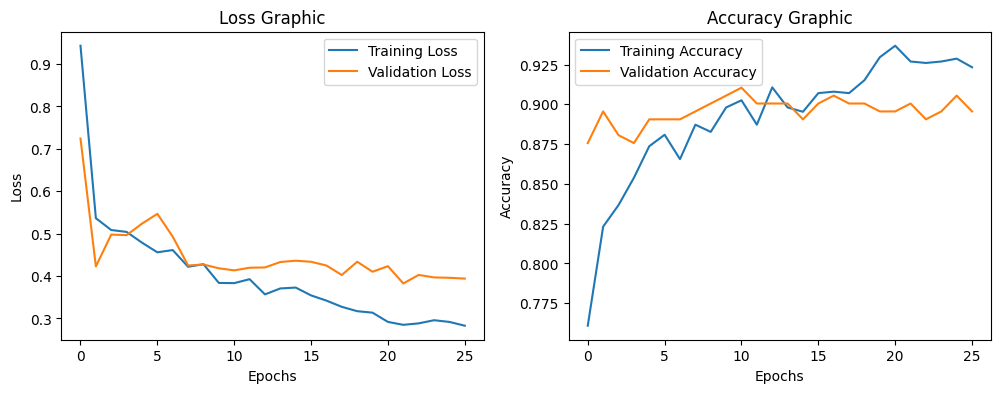

Carregando melhor modelo do fold para avaliação...
   Resultado Fold 3: Acc=0.9104, AUC=0.8249
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       175
           1       0.70      0.54      0.61        26

    accuracy                           0.91       201
   macro avg       0.82      0.75      0.78       201
weighted avg       0.90      0.91      0.91       201



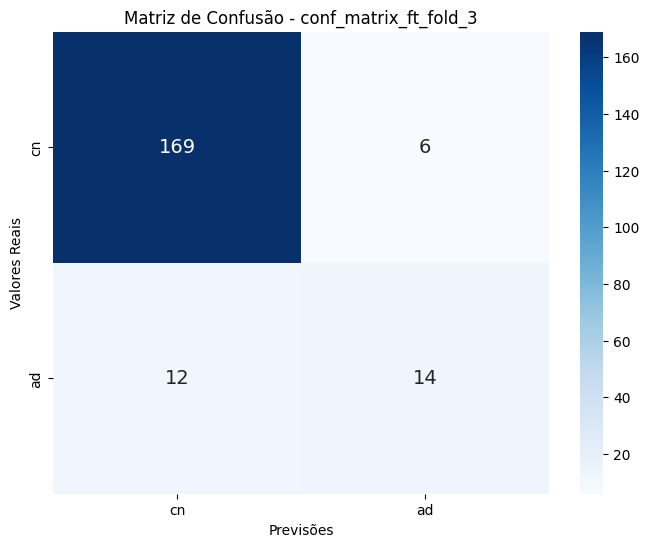

🧹 Limpando memória...

INICIANDO FOLD 4/5 (FINE-TUNING COM AUGMENTATION)
⏳ Gerando Augmentation e Balanceamento na RAM...
   > Balanceamento: Majoritária (0): 700 | Minoritária (1): 103
   > Alocando memória para 1112 amostras (float16). Shape final: (1112, 156, 195, 160, 1)
    Processando: 800/803...
Dados Augmentados na RAM! Shape: (1112, 156, 195, 160, 1)
Configurando tf.data Generators...
Carregando modelo base de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_2/binary_classifier_noise_200_epochs_batch_8_2_classes.keras
Pesos carregados com sucesso.
   Congelando camadas iniciais (0 a 12)...
🚀 Iniciando Fine-Tuning...
Epoch 1/50


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 46 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


    138/Unknown 13s 53ms/step - accuracy: 0.7283 - auc: 0.7939 - loss: 1.2200

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


139/139 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - accuracy: 0.7617 - auc: 0.8294 - loss: 0.9284 - val_accuracy: 0.8850 - val_auc: 0.8494 - val_loss: 0.5624 - learning_rate: 0.0010
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.8076 - auc: 0.8860 - loss: 0.6289 - val_accuracy: 0.8900 - val_auc: 0.8505 - val_loss: 0.4570 - learning_rate: 0.0010
Epoch 3/50
  1/139 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.7500 - auc: 0.8571 - loss: 1.2443

...

2026-01-13 13:29:37.342959: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813


139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9092 - auc: 0.9685 - loss: 0.3255 - val_accuracy: 0.8800 - val_auc: 0.8786 - val_loss: 0.3691 - learning_rate: 2.5000e-04
Epoch 21/50
  3/139 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.8333 - auc: 0.9944 - loss: 0.3198 

2026-01-13 13:29:44.660653: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813


139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.9137 - auc: 0.9713 - loss: 0.3158 - val_accuracy: 0.8800 - val_auc: 0.8831 - val_loss: 0.3662 - learning_rate: 2.5000e-04


2026-01-13 13:29:52.113474: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813


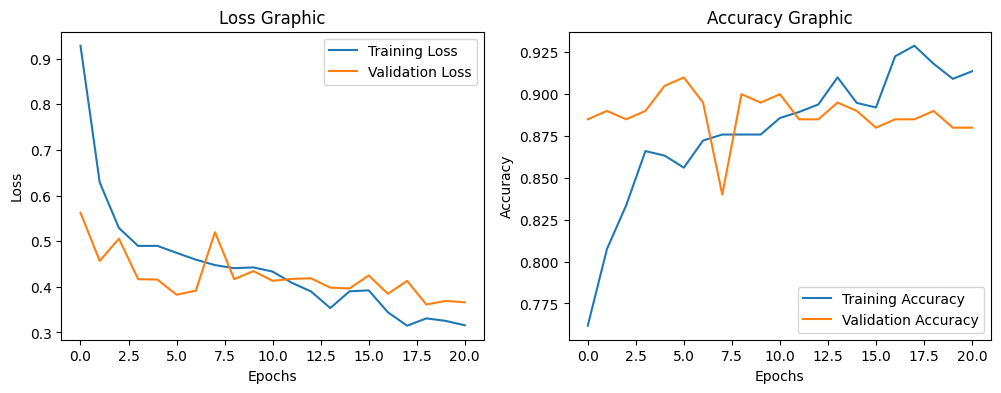

Carregando melhor modelo do fold para avaliação...


2026-01-13 13:29:56.305599: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


   Resultado Fold 4: Acc=0.9100, AUC=0.8783
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       175
           1       0.77      0.40      0.53        25

    accuracy                           0.91       200
   macro avg       0.84      0.69      0.74       200
weighted avg       0.90      0.91      0.90       200



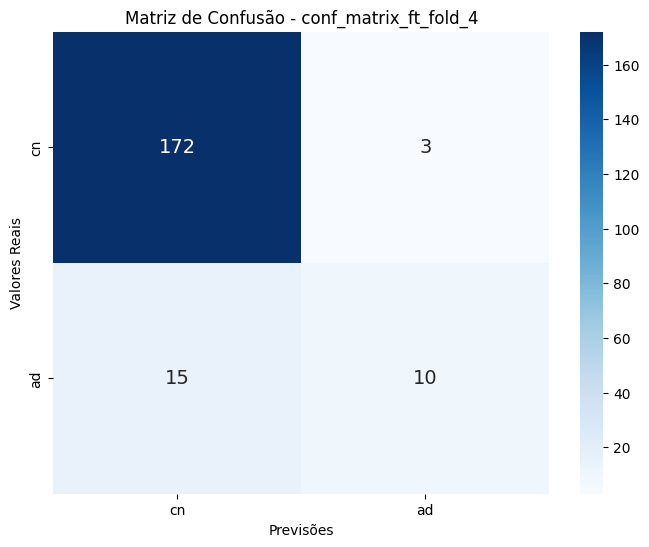

🧹 Limpando memória...

INICIANDO FOLD 5/5 (FINE-TUNING COM AUGMENTATION)
⏳ Gerando Augmentation e Balanceamento na RAM...
   > Balanceamento: Majoritária (0): 700 | Minoritária (1): 103
   > Alocando memória para 1112 amostras (float16). Shape final: (1112, 156, 195, 160, 1)
    Processando: 800/803...
Dados Augmentados na RAM! Shape: (1112, 156, 195, 160, 1)
Configurando tf.data Generators...
Carregando modelo base de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_2/binary_classifier_noise_200_epochs_batch_8_2_classes.keras
Pesos carregados com sucesso.
   Congelando camadas iniciais (0 a 12)...
🚀 Iniciando Fine-Tuning...
Epoch 1/50


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 46 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


    139/Unknown 12s 46ms/step - accuracy: 0.7523 - auc: 0.8311 - loss: 0.9248

2026-01-13 13:32:30.636266: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-01-13 13:32:30.636467: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


139/139 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.7761 - auc: 0.8516 - loss: 0.7780 - val_accuracy: 0.8750 - val_auc: 0.7359 - val_loss: 0.7233 - learning_rate: 0.0010
Epoch 2/50


...

139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9164 - auc: 0.9694 - loss: 0.3290 - val_accuracy: 0.8900 - val_auc: 0.8657 - val_loss: 0.3913 - learning_rate: 5.0000e-04
Epoch 17/50
  2/139 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1978 

2026-01-13 13:34:27.903217: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
2026-01-13 13:34:27.903314: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9092 - auc: 0.9566 - loss: 0.3609 - val_accuracy: 0.8950 - val_auc: 0.8886 - val_loss: 0.4467 - learning_rate: 5.0000e-04
Epoch 18/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9038 - auc: 0.9636 - loss: 0.3431 - val_accuracy: 0.8950 - val_auc: 0.8789 - val_loss: 0.4561 - learning_rate: 2.5000e-04
Epoch 19/50
  1/139 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1798

2026-01-13 13:34:42.426807: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.9164 - auc: 0.9747 - loss: 0.3099 - val_accuracy: 0.8950 - val_auc: 0.8312 - val_loss: 0.4825 - learning_rate: 2.5000e-04


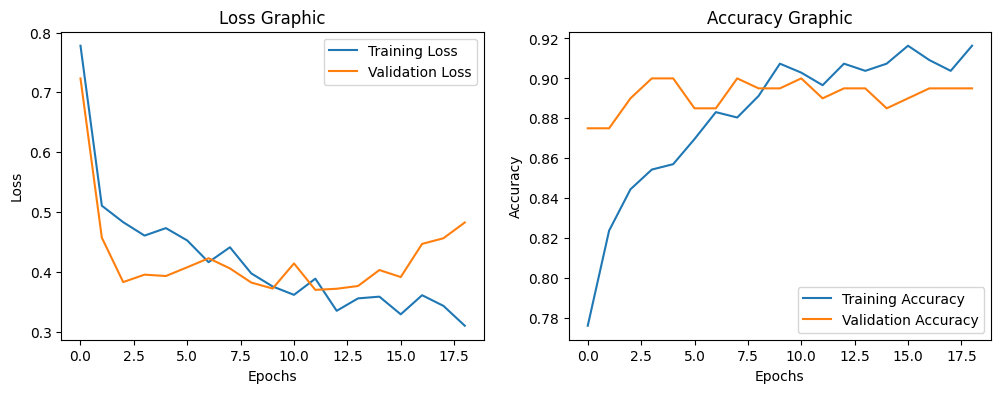

Carregando melhor modelo do fold para avaliação...


2026-01-13 13:34:54.171998: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13796950660790075813
2026-01-13 13:34:54.172075: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1982594999277412325


   Resultado Fold 5: Acc=0.9000, AUC=0.8925
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       175
           1       0.73      0.32      0.44        25

    accuracy                           0.90       200
   macro avg       0.82      0.65      0.69       200
weighted avg       0.89      0.90      0.88       200



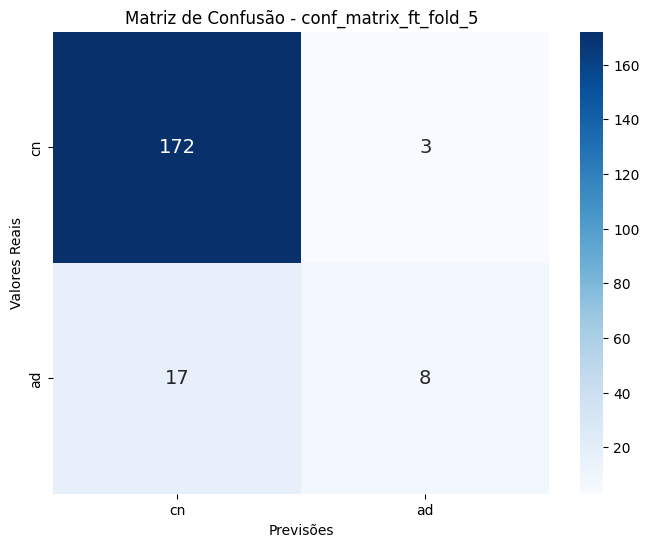

🧹 Limpando memória...


In [8]:
# FUNÇÕES AUXILIARES (VISUALIZAÇÃO)
def plot_training_history_binary(history, directory, title='training_history.png'):
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    save_path = os.path.join(directory, title)
    plt.savefig(save_path)
    plt.close() # Importante fechar para liberar memória da figura
    print(f"   Grafico de historico salvo em: {save_path}")

def save_confusion_matrix(y_true, y_pred, directory, fold_num):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['CN', 'AD'])
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
    ax.set_title(f"Confusion Matrix - Fold {fold_num}")
    
    save_path = os.path.join(directory, f"confusion_matrix_fold_{fold_num}.png")
    plt.savefig(save_path)
    plt.close()
    print(f"   Matriz de confusão salva em: {save_path}")

def augment_and_balance_in_ram(X_full, y_full, indices):
    # 1. Pega labels deste fold para contagem
    y_subset = y_full[indices]
    
    # 2. Identifica classe minoritária e majoritária
    counts = np.bincount(y_subset)
    minority_class = np.argmin(counts)
    majority_class = np.argmax(counts)
    n_minority = counts[minority_class]
    n_majority = counts[majority_class]
    
    print(f"   > Balanceamento: Majoritária ({majority_class}): {n_majority} | Minoritária ({minority_class}): {n_minority}")
    
    # 3. Calcula tamanho final
    total_final = n_majority + (n_minority * 4)
    
    # --- CORREÇÃO AQUI: Detecção Dinâmica de Shape ---
    sample_shape = X_full[0].shape
    
    # Se for (D, H, W), vira (D, H, W, 1). Se já for (D, H, W, C), mantém.
    if len(sample_shape) == 3:
        final_sample_shape = (*sample_shape, 1)
        needs_expansion = True # Indica que precisaremos expandir os originais
    else:
        final_sample_shape = sample_shape
        needs_expansion = False # Já tem canal

    final_shape = (total_final, *final_sample_shape)
    # -----------------------------------------------
    
    print(f"   > Alocando memória para {total_final} amostras (float16). Shape final: {final_shape}")
    
    # 4. Alocação
    try:
        X_aug = np.empty(final_shape, dtype=np.float16) 
        y_aug = np.empty((total_final,), dtype=np.int16)
    except MemoryError:
        print("ERRO FATAL: Memória RAM insuficiente para Augmentation.")
        raise
        
    # 5. Preenchimento e Augmentation
    cursor = 0
    total_indices = len(indices)
    
    for idx, i in enumerate(indices):
        orig = X_full[i] 
        lbl = y_full[i]
        
        # Prepara o original com o shape correto para inserção
        if needs_expansion:
            # (D, H, W) -> (D, H, W, 1)
            orig_ready = np.expand_dims(orig, axis=-1)
        else:
            # Já é (D, H, W, C)
            orig_ready = orig

        if lbl == majority_class:
            # Classe Majoritária: Copia apenas o original
            X_aug[cursor] = orig_ready
            y_aug[cursor] = lbl
            cursor += 1
        else:
            # Classe Minoritária: Original + 3 Augmentations
            
            # 1. Original
            X_aug[cursor] = orig_ready
            y_aug[cursor] = lbl
            cursor += 1
            
            # --- CORREÇÃO DO LOOP: Lógica condicional para Augmentation ---
            # Função auxiliar interna para garantir shape correto vindo do augment
            def ensure_shape(img_aug):
                # Se a função de augment retornou 3D, expande.
                if len(img_aug.shape) == 3:
                    return np.expand_dims(img_aug, axis=-1)
                # Se retornou 4D, verifica se bate com o target
                return img_aug

            # 2. Zoom
            zoom_img = proc_dados.augment_zoom(orig) 
            X_aug[cursor] = ensure_shape(zoom_img)
            y_aug[cursor] = lbl
            cursor += 1
            
            # 3. Shift
            shift_img = proc_dados.augment_shift(orig)
            X_aug[cursor] = ensure_shape(shift_img)
            y_aug[cursor] = lbl
            cursor += 1
            
            # 4. Rotation
            rot_img = proc_dados.augment_rotation(orig)
            X_aug[cursor] = ensure_shape(rot_img)
            y_aug[cursor] = lbl
            cursor += 1
            
        if idx % 100 == 0:
            print(f"    Processando: {idx}/{total_indices}...", end='\r')
            
    print(f"\nDados Augmentados na RAM! Shape: {X_aug.shape}")
    
    # 6. Embaralhar
    shuf_idxs = np.arange(total_final)
    np.random.shuffle(shuf_idxs)
    
    return X_aug[shuf_idxs], y_aug[shuf_idxs]

def numpy_generator(x_data, y_data):
    for i in range(len(x_data)):
        yield x_data[i].astype(np.float16), y_data[i]

# Itera sobre os dados unificados (X_3t_all)
for fold_idx, (train_index, val_index) in enumerate(skf.split(X_3t_all, y_3t_all)):
    print(f"\n{'='*40}")
    print(f"INICIANDO FOLD {fold_idx+1}/{K_FOLDS} (FINE-TUNING COM AUGMENTATION)")
    print(f"{'='*40}")

    fold_dir = os.path.join(results_dir, f"fold_ft_{fold_idx+1}")
    os.makedirs(fold_dir, exist_ok=True)

    # --- A. PREPARAÇÃO DOS DADOS ---
    
    # VALIDAÇÃO: 
    X_val_fold = X_3t_all[val_index]
    if len(X_val_fold.shape) == 3:
        X_val_fold = np.expand_dims(X_val_fold, axis=-1)
    X_val_fold = X_val_fold.astype(np.float16)
    y_val_fold = y_3t_all[val_index]

    # TREINO: 
    # Aplicamos a função de Augmentation na RAM
    print("⏳ Gerando Augmentation e Balanceamento na RAM...")
    try:
        X_train_aug, y_train_aug = augment_and_balance_in_ram(X_3t_all, y_3t_all, train_index)
    except MemoryError:
        print("FATAL: Memória insuficiente no augmentation. Parando execução.")
        break
    except Exception as e:
        print(f"Erro no augmentation: {e}")
        break

    # --- B. CONFIGURAR GENERATORS (TF.DATA) ---
    print("Configurando tf.data Generators...")
    
    # Especificações dos tensores
    # Treino é float16 (conforme saído do augment_and_balance)
    train_spec_img = tf.TensorSpec(shape=X_train_aug.shape[1:], dtype=tf.float16) 
    train_spec_lbl = tf.TensorSpec(shape=(), dtype=tf.int16)
    
    # Validação é float16
    val_spec_img = tf.TensorSpec(shape=X_val_fold.shape[1:], dtype=tf.float16)
    val_spec_lbl = tf.TensorSpec(shape=(), dtype=tf.int16)

    # Dataset Treino (Generator converte f16 -> f32 on-the-fly)
    train_dataset = tf.data.Dataset.from_generator(
        lambda: numpy_generator(X_train_aug, y_train_aug),
        output_signature=(train_spec_img, train_spec_lbl)
    )
    # Shuffle buffer e Prefetch
    train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Dataset Validação
    val_dataset = tf.data.Dataset.from_generator(
        lambda: numpy_generator(X_val_fold, y_val_fold),
        output_signature=(val_spec_img, val_spec_lbl)
    )
    val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # --- C. MODELO E TRANSFER LEARNING ---
    print(f"Carregando modelo base de: {pretrained_model_path}")
    input_shape = X_train_aug.shape[1:] # ex: (156, 195, 160, 1)

    # 2. Carrega pesos
    try:
        model_ft = load_model(pretrained_model_path)
        print("Pesos carregados com sucesso.")
    except Exception as e:
        print(f"ERRO CRÍTICO ao carregar pesos: {e}")
        break

    # 3. Congela camadas iniciais (Bloco 1 e 2)
    # Ajuste o range se quiser congelar mais ou menos camadas
    print("   Congelando camadas iniciais (0 a 12)...")
    for i in range(13):
        model_ft.layers[i].trainable = False

    # 4. Compila
    model_ft.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
        loss='binary_crossentropy', 
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    # Callbacks
    model_name = f"model_ft_fold_{fold_idx+1}.keras"
    model_save_path = os.path.join(fold_dir, model_name)
    
    callbacks_list = [
        ModelCheckpoint(model_save_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]

    # --- D. TREINAMENTO ---
    print("🚀 Iniciando Fine-Tuning...")
    history = model_ft.fit(
        train_dataset,
        epochs=EPOCHS,
        validation_data=val_dataset,
        callbacks=callbacks_list,
        verbose=1
    )
    
    # Salva gráfico histórico
    try: met_vil.plot_training_history_binary(history, fold_dir)
    except: pass

    # --- E. AVALIAÇÃO E PREDIÇÃO ---
    print("Carregando melhor modelo do fold para avaliação...")
    best_model = models.load_model(model_save_path)
    
    # Avaliação numérica
    loss, acc, auc = best_model.evaluate(val_dataset, verbose=0)
    fold_accuracies.append(acc)
    fold_aucs.append(auc)
    print(f"   Resultado Fold {fold_idx+1}: Acc={acc:.4f}, AUC={auc:.4f}")

    # Predição (Usando o gerador da validação para não estourar RAM)
    # model.predict(val_dataset) retorna na ordem correta do generator
    preds_prob = best_model.predict(val_dataset, verbose=0)
    
    # Binariza (Threshold 0.5)
    pred_labels = (preds_prob > 0.5).astype(int).flatten()
    true_labels = y_val_fold # Já temos na RAM
    
    # Garante shapes compatíveis (caso o batching do generator corte algo, embora raro no predict)
    limit = min(len(pred_labels), len(true_labels))
    pred_labels = pred_labels[:limit]
    true_labels = true_labels[:limit]

    # Relatórios
    met_vil.get_classification_report(true_labels, pred_labels, fold_dir, f'report_ft_fold_{fold_idx+1}')
    met_vil.plot_confusion_matrix(true_labels, pred_labels, fold_dir, f'conf_matrix_ft_fold_{fold_idx+1}', ['cn', 'ad'])

    # Acumula para relatório global
    all_true_labels.extend(true_labels)
    all_pred_labels.extend(pred_labels)

    # --- F. LIMPEZA DE MEMÓRIA ---
    print("🧹 Limpando memória...")
    del X_train_aug, y_train_aug, X_val_fold, y_val_fold
    del train_dataset, val_dataset, model_ft, best_model, history
    tf.keras.backend.clear_session()
    gc.collect()


=== FINE-TUNING FINALIZADO ===
Acurácia Média: 0.9013 (+/- 0.0079)
AUC Média: 0.8464 (+/- 0.0348)


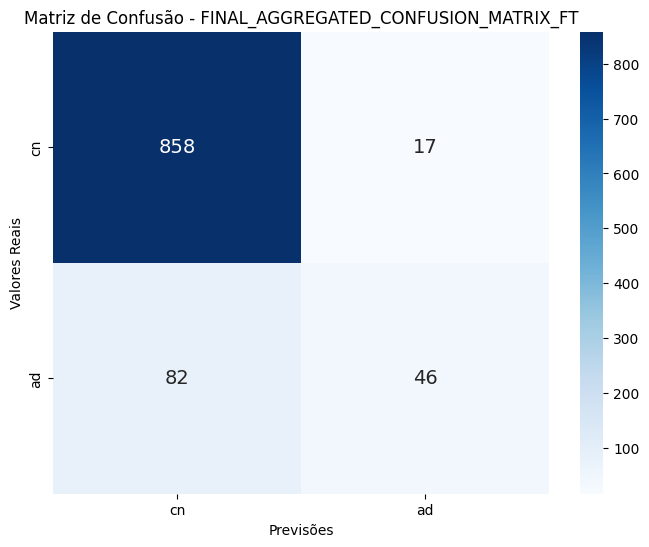

              precision    recall  f1-score   support

           0       0.91      0.98      0.95       875
           1       0.73      0.36      0.48       128

    accuracy                           0.90      1003
   macro avg       0.82      0.67      0.71      1003
weighted avg       0.89      0.90      0.89      1003



In [9]:
# ==========================================
# 4. RESULTADOS FINAIS AGREGADOS
# ==========================================
print("\n=== FINE-TUNING FINALIZADO ===")
print(f"Acurácia Média: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"AUC Média: {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")

# Gera Matriz Global
final_true = np.array(all_true_labels)
final_pred = np.array(all_pred_labels)

if len(final_true) > 0:
    met_vil.plot_confusion_matrix(
        final_true, 
        final_pred, 
        results_dir, 
        'FINAL_AGGREGATED_CONFUSION_MATRIX_FT', 
        ['cn', 'ad']
    )
    
    met_vil.get_classification_report(
        final_true, 
        final_pred, 
        results_dir, 
        'FINAL_AGGREGATED_REPORT_FT'
    )